# Układy równań liniowych
Główny cel laboratorium: porównanie jak liczy układ równań liniowych zadany macierzą źle i dobrze uwarunkowaną, jaki wpływ ma precyzja arytmetyczna (`float` vs `double`), a także jak duży zysk w postaci czasu działania programu można zyskać stosując dedykowany algorytm dla problemu macierz trójdiagonalnej, zamiast prostego algorytmu Gaussa.

## Część pierwsza: Macierz źle uwarunkowana
Mamy rozwiązać układ równań:
$$
    A \cdot X = b
$$
gdzie:
$$
    A = [a_{ij}]_{n \times n}, \quad i, j \in \{1, 2, \dots, n\} \\[4ex]
    
    \begin{cases}
        a_{ij} = 1, \quad &i = 1, j \in \{1, 2, \dots, n\} \\[2ex]
        a_{ij} = \frac{1}{i + j - 1}, \quad &i \in \{2, 3, \dots, n\}, j \in \{1, 2, \dots, n\}
    \end{cases} \\[4ex]

    X \ \text{to wektor o wymiarach} \ n \times 1 \text{, który stanowi permutację ze zbioru} \ \{-1, 1\}
$$
natomiast $b$ wyliczamy na podstawie $A$ oraz $X$.

Naszym zadaniem jest, dla pojedynczej i podwójnej precyzji, znaleźć z poniższą normą (mój wybór padł na błąd bezwzględny):
$$
    \|X\|_{\max} = \max_{i \in 1, \dots, n} (|x_i - \overline{x_i}|), \quad \text{gdzie} \ x_i \ \text{to wartość referencyjna, natomiast} \ \overline{x_i} \ \text{to wartość wyliczona}
$$

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import tracemalloc

from typing import Type, List, Dict, Any
from pathlib import Path

SEED = 11052026
K = 6
M = 5

In [46]:
def generate_first_matrix(n: int, precision: Type[np.number] = np.float64) -> np.ndarray:
    """
    Generates an n x n matrix based on a specific index-based formula.
    
    The formula is defined as:
    - a_1j = 1
    - a_ij = 1 / (i + j - 1) for i != 1
    where i, j are 1-based indices.

    Parameters:
    -------
        n (int): The size of the square matrix.
        precision (Type[np.number]): The NumPy floating-point dtype (e.g., np.float32, np.float64).

    Returns:
    -------
        np.ndarray: Calculated matrix of shape (n, n) with the specified precision.
        
    Raises:
    -------
    ValueError
        If matrix dimension n is not a positive integer.
    """
    
    if not isinstance(n, int) or n <= 0:
        raise ValueError("Matrix dimension n must be a positive integer")
    
    i = np.arange(1, n + 1, dtype=precision).reshape(-1, 1)
    j = np.arange(1, n + 1, dtype=precision).reshape(1, -1)
    
    matrix = 1.0 / (i + j - 1.0)
    
    matrix[0, :] = 1.0
    
    return matrix


### Reużywalny kod dla $X$ oraz $b$
O ile kod dla wyliczania $A$ jest specyficzny dla przykładu, tak kod znajdujący się poniżej, służący generowaniu losowej permutacji $-1$ oraz $1$ dla wektora $X$, a także wyliczania wektora $b$ będzie stanowił podstawę dla obliczeń późniejszych punktów.

In [47]:
def generate_x_vector(n: int, precision: Type[np.number] = np.float64) -> np.ndarray:
    """
    Generates a vector X of size n, which is a random permutation of values -1 and 1.
    
    Parameters:
    -------
        n (int): The size of the vector.
        precision (Type[np.number]): The NumPy floating-point dtype.

    Returns:
    -------
        np.ndarray: Vector of shape (n,) containing random -1.0 or 1.0 values.
    """
    
    rng = np.random.default_rng(SEED)
    x = rng.choice([-1.0, 1.0], size=n).astype(precision)
    return x

In [48]:
def calculate_b_vector(A: np.ndarray, x: np.ndarray) -> np.ndarray:
    """
    Calculates the constant terms vector b = A * x.
    
    Parameters:
    -------
        A (np.ndarray): The coefficient matrix.
        x (np.ndarray): The solution vector.

    Returns:
    -------
        np.ndarray: The resulting vector b.
    """

    return A @ x

## Algorytm eliminacji Gaussa
Algorytm eliminacji Gaussa rozwiązujący układ równań liniowych $A \cdot X = b$. Wykorzystuje częściowy wybór elementu podstawowego (*partial pivoting*).

In [49]:
import numpy as np

def gaussian_elimination(A: np.ndarray, b: np.ndarray, precision: Type[np.number] = np.float64) -> np.ndarray:
    """
    Solves a system of linear equations Ax = b using Gaussian elimination 
    with partial pivoting.

    Parameters:
    ----------
    A : np.ndarray
        Coefficient matrix of shape (n, n). 
        Should be a 2D numerical array.
    b : np.ndarray
        Constant terms vector of shape (n,) or (n, 1).

    Returns:
    -------
    np.ndarray
        Solution vector x of shape (n,).

    Raises:
    -------
    ValueError
        If matrix A is not square, the dimensions of A and b do not match,
        or if the matrix is singular (no unique solution).
    """
    # 1. Dimension validation
    n = A.shape[0]
    if A.shape[1] != n:
        raise ValueError("Matrix A must be a square matrix.")
    if b.shape[0] != n:
        raise ValueError("Dimensions of matrix A and vector b do not match.")

    # 2. Initialize floating-point copies
    # We work on copies to avoid modifying the original data 
    # provided by the user and to prevent integer division issues.
    A_aug = np.array(A, dtype=precision)
    b_aug = np.array(b, dtype=precision).flatten()
    
    # 3. Forward Elimination phase
    for i in range(n):
        # Partial pivoting: find the largest element in the current column below the diagonal
        max_row_index = np.argmax(np.abs(A_aug[i:n, i])) + i
        
        # Protection against singular matrix
        if A_aug[max_row_index, i] == 0.0:
            raise ValueError(f"Encountered exact zero pivot at column {i}. Matrix is singular.")
            
        # If the largest element is not on the diagonal, swap rows
        if max_row_index != i:
            A_aug[[i, max_row_index]] = A_aug[[max_row_index, i]]
            b_aug[[i, max_row_index]] = b_aug[[max_row_index, i]]
            
        # Actual Gaussian elimination (zeroing elements below the diagonal)
        for j in range(i + 1, n):
            # Calculate the multiplier
            multiplier = A_aug[j, i] / A_aug[i, i]
            # Subtract the multiplied i-th row from the j-th row.
            # Using numpy vectorized operations for performance: A_aug[j, i:]
            A_aug[j, i:] -= multiplier * A_aug[i, i:]
            b_aug[j] -= multiplier * b_aug[i]

    # 4. Back Substitution phase
    x = np.zeros(n, dtype=precision)
    for i in range(n - 1, -1, -1):
        # Sum the products of already calculated 'x' and coefficients from the current row
        dot_product = np.sum(A_aug[i, i+1:] * x[i+1:])
        x[i] = (b_aug[i] - dot_product) / A_aug[i, i]
        
    return x

### Norma (błąd bezwzględny)
Jako normę przyjąłem maksymalny błąd bezwzględny po elementach wektorów. Tak, jak to zostało opisane w nagłówku:
$$
    \|X\|_{\max} = \max_{i \in 1, \dots, n} (|x_i - \overline{x_i}|), \quad \text{gdzie} \ x_i \ \text{to wartość referencyjna, natomiast} \ \overline{x_i} \ \text{to wartość wyliczona}
$$

In [50]:
def max_absolute_error(x_ref: np.ndarray, x_calc: np.ndarray) -> float:
    """
    Calculates the maximum absolute error (infinity norm of the error vector) 
    between the reference solution and the calculated solution.

    Parameters:
    ----------
    x_ref : np.ndarray
        The reference (exact) solution vector.
    x_calc : np.ndarray
        The calculated (approximate) solution vector.

    Returns:
    -------
    float
        The maximum absolute difference between corresponding elements.
        
    Raises:
    -------
    ValueError
        If the shapes of x_ref and x_calc do not match.
    """
    if x_ref.shape != x_calc.shape:
        raise ValueError("Dimensions of reference and calculated vectors must match.")
        
    return float(np.max(np.abs(x_ref - x_calc)))

## Eksperyment numeryczny: zadanie 1
Mamy już wszystkie funkcje potrzebne do wykonania zadania pierwszego. Interesuje nas wartość normy maksimum w zależności od precyzji, oraz rozmiaru macierzy. Poniższy kod zrzuca te dane do jednego pliku CSV, na podstawie którego zostanie sporządzone sprawozdanie.

In [51]:
def generate_experiment_data(filename: str = "exercise1_data.csv") -> pd.DataFrame:
    """
    Runs the Gaussian elimination experiment for matrix sizes n from 2 to 20,
    calculating the max absolute error and execution time for both float32 and float64.
    Saves the results to a CSV file.

    Parameters:
    ----------
    filename : str
        The name of the output CSV file.

    Returns:
    -------
    pd.DataFrame
        A DataFrame containing the aggregated results of the experiment.
    """
    
    # Create a designated data/ folder for CSV files
    filepath = Path("data") / filename
    filepath.parent.mkdir(parents=True, exist_ok=True)
    
    # We will store the results as a list of dictionaries, 
    # which is very efficient for building pandas DataFrames.
    results: List[Dict[str, Any]] = []
    
    # Loop over matrix sizes from 2 to 20
    for n in range(2, 21):
        row_data = {"n": n}
        
        # Test both precisions
        for precision_name, precision in [("float32", np.float32), ("float64", np.float64)]:
            
            # 1. Generate inputs
            A = generate_first_matrix(n, precision)
            x_ref = generate_x_vector(n, precision)
            b = calculate_b_vector(A, x_ref)
            x_calc = gaussian_elimination(A, b, precision)
            
            # 2. Calculate max absolute error
            error = max_absolute_error(x_ref, x_calc)
            
            # 4. Save results to the current row
            row_data[f"||x||_max_{precision_name}"] = error
            
        results.append(row_data)
        
    # Create a DataFrame from the collected data
    df = pd.DataFrame(results)
    
    # Format the scientific notation to match the table aesthetics (e.g., 2.3842e-07)
    for col in df.columns:
        if col != "n":
            df[col] = df[col].apply(lambda val: f"{val:.4e}")
    
    # Save the DataFrame to a CSV file without the index column
    df.to_csv(filepath, index=False)
    print(f"Experiment completed. Data successfully saved to '{filename}'.")
    
    return df

results_df = generate_experiment_data()
display(results_df.head())

Experiment completed. Data successfully saved to 'exercise1_data.csv'.


,n,||x||_max_float32,||x||_max_float64
0,2,2.3842e-07,2.2204e-16
1,3,5.2452e-06,2.6978e-14
2,4,2.5749e-04,1.7986e-13
3,5,4.0412e-03,5.9348e-12
4,6,4.9290e-02,1.4487e-10


### Wykres normy maksimum w zależności od rozmiaru macierzy

Saved plot to: plots\exercise1_data_max_norm_n.png


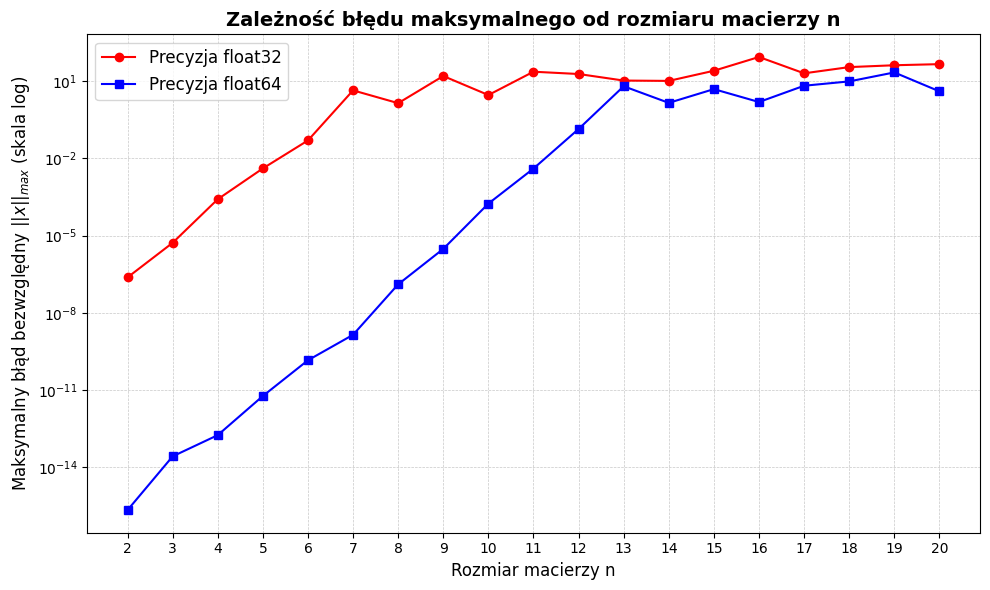

In [52]:
def plot_error_vs_n(csv_filename: str) -> None:
    """
    Reads experimental results from a CSV file and plots the maximum absolute error
    (||x||_max) as a function of matrix size (n) for both float32 and float64 precisions.
    
    Parameters:
    ----------
    csv_filename : str
        The name of the CSV file containing the experiment data.
        
    Raises:
    ----------
    FileNotFoundError
        If a file with name csv_filename doesn't exist
    """
    # 0. Create a path to the csv_filename
    path = Path("data") / csv_filename
    if not path.exists():
        raise FileNotFoundError(f"Couldn't locate file {path}")
    
    # 1. Load data
    df = pd.read_csv(path)
    
    # 2. Setup the plot
    plt.figure(figsize=(10, 6))
    
    # 3. Plot both series using semi-logarithmic scale (logarithmic Y-axis)
    # We use different markers ('o' and 's') and colors to easily distinguish the lines
    plt.semilogy(df["n"], df["||x||_max_float32"], marker='o', linestyle='-', color='red', label='Precyzja float32')
    plt.semilogy(df["n"], df["||x||_max_float64"], marker='s', linestyle='-', color='blue', label='Precyzja float64')
    
    # 4. Styling and labels
    plt.title('Zależność błędu maksymalnego od rozmiaru macierzy n', fontsize=14, fontweight='bold')
    plt.xlabel('Rozmiar macierzy n', fontsize=12)
    plt.ylabel('Maksymalny błąd bezwzględny $||x||_{max}$ (skala log)', fontsize=12)
    
    # Set x-ticks to be exactly the integer sizes of the matrices
    plt.xticks(df["n"])
    
    # Add a grid for both major and minor ticks (helpful on log scales)
    plt.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.7)
    
    # Add legend
    plt.legend(fontsize=12)
    
    # Adjust layout to not cut off labels
    plt.tight_layout()
    
    # 5. Save the plot
    
    filename = Path(csv_filename).stem + "_max_norm_n.png"
    save_path = Path("plots") / filename
    save_path.parent.mkdir(parents=True, exist_ok=True)
    
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    print(f"Saved plot to: {save_path}")
    
    # Display the plot in the notebook as well
    plt.show()

plot_error_vs_n("exercise1_data.csv")

## Część druga: Macierz dobrze uwarunkowana
Mamy rozwiązać układ równań:
$$
    A \cdot X = b
$$
gdzie:
$$
    A = [a_{ij}]_{n \times n}, \quad i, j \in \{1, 2, \dots, n\} \\[4ex]
    
    \begin{cases}
        a_{ij} = \frac{2i}{j}, \quad &j \geq i \\[2ex]
        a_{ij} = a_{ji}, \quad &j < i
    \end{cases} \\[4ex]

    X \ \text{to wektor o wymiarach} \ n \times 1 \text{, który stanowi permutację ze zbioru} \ \{-1, 1\}
$$
natomiast $b$ wyliczamy na podstawie $A$ oraz $X$.

Naszym zadaniem jest, dla pojedynczej i podwójnej precyzji, znaleźć z poniższą normą (mój wybór padł na błąd bezwzględny):
$$
    \|X\|_{\max} = \max_{i \in 1, \dots, n} (|x_i - \overline{x_i}|), \quad \text{gdzie} \ x_i \ \text{to wartość referencyjna, natomiast} \ \overline{x_i} \ \text{to wartość wyliczona}
$$

In [53]:
def generate_second_matrix(n: int, precision: Type[np.number] = np.float64) -> np.ndarray:
    """
    Generates an n x n matrix based on a specific index-based formula.
    
    The formula is defined as:
    - a_ij = 2i / j, j >= i
    - a_ij = a_ji,   j < i
    where i, j are 1-based indices.

    Parameters:
    -------
        n (int): The size of the square matrix.
        precision (Type[np.number]): The NumPy floating-point dtype (e.g., np.float32, np.float64).

    Returns:
    -------
        np.ndarray: Calculated matrix of shape (n, n) with the specified precision.
        
    Raises:
    -------
    ValueError
        If matrix dimension n is not a positive integer.
    """
    
    if not isinstance(n, int) or n <= 0:
        raise ValueError("Matrix dimension n must be a positive integer")
    
    i = np.arange(1, n + 1, dtype=precision).reshape(-1, 1)
    j = np.arange(1, n + 1, dtype=precision).reshape(1, -1)
    
    # Use broadcasting to find min(i, j) and max(i, j) for every element in the matrix
    min_ij = np.minimum(i, j)
    max_ij = np.maximum(i, j)
    
    # Calculate the matrix based on the generalized formula
    # We cast 2.0 to the requested precision to prevent silent upcasting to float64
    two = np.array(2.0, dtype=precision)
    matrix = (two * min_ij) / max_ij
    
    return matrix

## Eksperyment numeryczny: zadanie 2
Mamy już kod generujący macierz A z zadania drugiego w określonej precyzji, a reszta kodu jest reużywalna. Zarówno generowanie wektora $X$ jak i obliczanie wektora $B$ pozostaje bez zmian. Podobnie z algorytmem eliminacji Gaussa. Mamy więc wszystkie klocki potrzebne do przeprowadzenia eksperymentu z zadania drugiego, czyli eksperymentu analogicznego do pierwszego.

In [54]:
def generate_experiment_two_data(filename: str = "exercise2_data.csv") -> pd.DataFrame:
    """
    Runs the Gaussian elimination experiment for matrix sizes n from 2 to 20,
    calculating the max absolute error and execution time for both float32 and float64.
    Saves the results to a CSV file.

    Parameters:
    ----------
    filename : str
        The name of the output CSV file.

    Returns:
    -------
    pd.DataFrame
        A DataFrame containing the aggregated results of the experiment.
    """
    
    # Create a designated data/ folder for CSV files
    filepath = Path("data") / filename
    filepath.parent.mkdir(parents=True, exist_ok=True)
    
    # We will store the results as a list of dictionaries, 
    # which is very efficient for building pandas DataFrames.
    results: List[Dict[str, Any]] = []
    
    # Loop over matrix sizes from 2 to 20 (same as the first experiment)
    for n in range(2, 21):
        row_data = {"n": n}
        
        # Test both precisions
        for precision_name, precision in [("float32", np.float32), ("float64", np.float64)]:
            
            # 1. Generate inputs
            A = generate_second_matrix(n, precision)
            x_ref = generate_x_vector(n, precision)
            b = calculate_b_vector(A, x_ref)
            x_calc = gaussian_elimination(A, b, precision)
            
            # 2. Calculate max absolute error
            error = max_absolute_error(x_ref, x_calc)
            
            # 4. Save results to the current row
            row_data[f"||x||_max_{precision_name}"] = error
            
        results.append(row_data)
    
    # Loop over matrix sizes 50, 100, ..., 250, to showcase 
    # that everything is being calculated properly
    for n in range(50, 300, 50):
        row_data = {"n": n}
        
        # Test both precisions
        for precision_name, precision in [("float32", np.float32), ("float64", np.float64)]:
            
            # 1. Generate inputs
            A = generate_second_matrix(n, precision)
            x_ref = generate_x_vector(n, precision)
            b = calculate_b_vector(A, x_ref)
            x_calc = gaussian_elimination(A, b, precision)
            
            # 2. Calculate max absolute error
            error = max_absolute_error(x_ref, x_calc)
            
            # 4. Save results to the current row
            row_data[f"||x||_max_{precision_name}"] = error
            
        results.append(row_data)
    
    # Create a DataFrame from the collected data
    df = pd.DataFrame(results)
    
    # Format the scientific notation to match the table aesthetics (e.g., 2.3842e-07)
    for col in df.columns:
        if col != "n":
            df[col] = df[col].apply(lambda val: f"{val:.4e}")
    
    # Save the DataFrame to a CSV file without the index column
    df.to_csv(filepath, index=False)
    print(f"Experiment completed. Data successfully saved to '{filename}'.")
    
    return df

results_df = generate_experiment_two_data()
display(results_df.head())

Experiment completed. Data successfully saved to 'exercise2_data.csv'.


,n,||x||_max_float32,||x||_max_float64
0,2,0.0000e+00,0.0000e+00
1,3,2.3842e-07,0.0000e+00
2,4,6.5565e-07,8.8818e-16
3,5,4.7684e-07,8.8818e-16
4,6,7.1526e-07,8.8818e-16


### Wykres normy maksimum w zależności od rozmiaru macierzy (dla zadania 2)

Saved plot to: plots\exercise2_data_max_norm_n.png


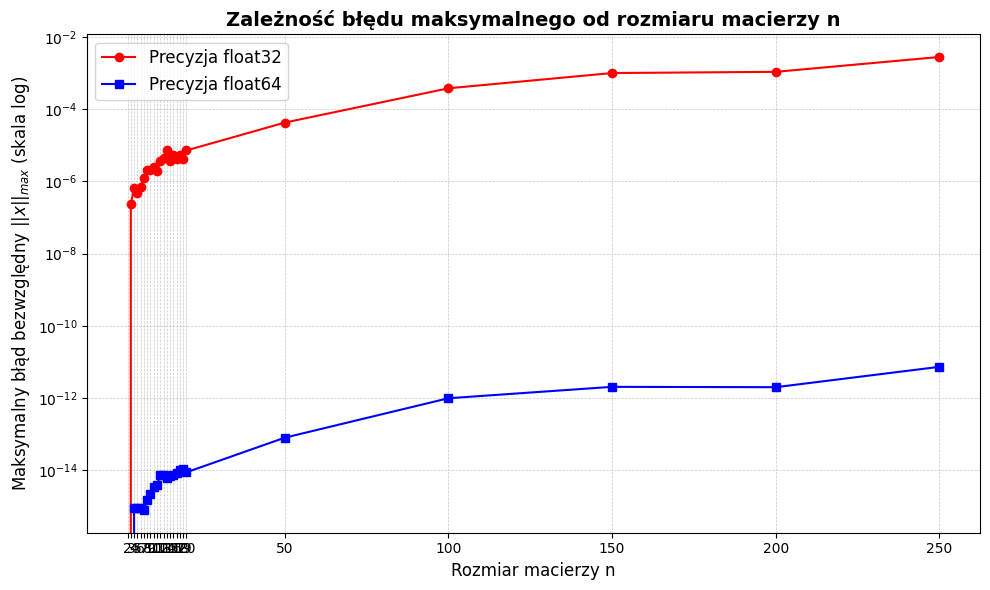

In [55]:
plot_error_vs_n("exercise2_data.csv")

### Obliczanie współczynnika uwarunkowania
Aby uzasadnić różnicę w dokładnościach między obliczeniami na pierwszej i drugiej wersji macierzy $A$, obliczono współczynnik uwarunkowania obu macierzy w zależności od ich rozmiaru.

In [56]:
def generate_condition_number_data(filename: str | Path = "data/exercise1_cond_data.csv") -> pd.DataFrame:
    """
    Calculates the condition number for Matrix I and Matrix II across sizes n from 2 to 20,
    for both float32 and float64 precisions. Saves the output to a CSV file.
    
    Parameters:
    ----------
    filename : str | Path
        The output path for the CSV file.
        
    Returns:
    -------
    pd.DataFrame
        DataFrame containing the calculated condition numbers.
    """
    output_path = Path(filename)
    results: List[Dict[str, Any]] = []
    
    print("Calculating condition numbers. This might take a moment for larger matrices...")
    
    for n in range(2, 21):
        row_data = {"n": n}
        
        for precision_name, precision in [("float32", np.float32), ("float64", np.float64)]:
            # 1. Generate both matrices
            A1 = generate_first_matrix(n, precision)
            A2 = generate_second_matrix(n, precision)
            
            # 2. Calculate condition numbers using numpy's linear algebra module
            # We use the default 2-norm condition number
            cond_A1 = np.linalg.cond(A1)
            cond_A2 = np.linalg.cond(A2)
            
            # 3. Store results using keys that map cleanly to the table structure
            row_data[f"cond_A1_{precision_name}"] = cond_A1
            row_data[f"cond_A2_{precision_name}"] = cond_A2
            
        results.append(row_data)
        
    for n in range(50, 250, 50):
        row_data = {"n": n}
        
        for precision_name, precision in [("float32", np.float32), ("float64", np.float64)]:
            # 1. Generate both matrices
            A1 = generate_first_matrix(n, precision)
            A2 = generate_second_matrix(n, precision)
            
            # 2. Calculate condition numbers using numpy's linear algebra module
            # We use the default 2-norm condition number
            cond_A1 = np.linalg.cond(A1)
            cond_A2 = np.linalg.cond(A2)
            
            # 3. Store results using keys that map cleanly to the table structure
            row_data[f"cond_A1_{precision_name}"] = cond_A1
            row_data[f"cond_A2_{precision_name}"] = cond_A2
            
        results.append(row_data)
        
    # Create the DataFrame
    df = pd.DataFrame(results)
    
    # Format values to scientific notation with 4 decimal places (e.g., 1.8000e+01)
    for col in df.columns:
        if col != "n":
            df[col] = df[col].apply(lambda val: f"{val:.4e}")
            
    # Ensure the target directory exists and save to CSV
    output_path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(output_path, index=False)
    
    print(f"Successfully generated and saved condition number data to: {output_path}")
    return df

cond_df = generate_condition_number_data("data/cond_data.csv")
display(cond_df.head())

Calculating condition numbers. This might take a moment for larger matrices...
Successfully generated and saved condition number data to: data\cond_data.csv


,n,cond_A1_float32,cond_A2_float32,cond_A1_float64,cond_A2_float64
0,2,1.4096e+01,3.0000e+00,1.4096e+01,3.0000e+00
1,3,4.8292e+02,6.6633e+00,4.8292e+02,6.6633e+00
2,4,1.7033e+04,1.2206e+01,1.7033e+04,1.2206e+01
3,5,5.9238e+05,1.9655e+01,5.9188e+05,1.9655e+01
4,6,2.0957e+07,2.9040e+01,2.0379e+07,2.9040e+01


## Część trzecia: Macierz trójdiagonalna
Mamy rozwiązać układ równań:
$$
    A \cdot X = b
$$
gdzie:
$$
    A = [a_{ij}]_{n \times n}, \quad i, j \in \{1, 2, \dots, n\}, \quad k = 6, m = 5 \\[4ex]
    
    \begin{cases}
        a_{i,i} = k \\
        a_{i,i+1} = \frac{1}{i+m} \\
        a_{i,i-1} = \frac{k}{i+m+1} \quad &\text{dla } i > 1 \\
        a_{i,j} = 0 \quad &\text{dla } j < i-1 \text{ oraz } j > i+1
    \end{cases} \\[4ex]


    X \ \text{to wektor o wymiarach} \ n \times 1 \text{, który stanowi permutację ze zbioru} \ \{-1, 1\}
$$
natomiast $b$ wyliczamy na podstawie $A$ oraz $X$.

Powyższy układ należy rozwiązać algorytmem Gaussa oraz algorytmem Thomasa, zbadać dokładność otrzymanego rozwiązania (reużywamy tutaj zdefiniowanej wcześniej normy maksimum), a także szybkość działania algorytmu i jego zasobożerność w sensie zużycia pamięci.

In [57]:
def generate_third_matrix(n: int, precision: Type[np.number] = np.float64) -> np.ndarray:
    """
    Generates an n x n tridiagonal matrix based on a specific index-based formula.
    
    The formula is defined as:
    - a_{i,i} = k
    - a_{i,i+1} = 1 / (i + m)
    - a_{i,i-1} = k / (i + m + 1) for i > 1
    - a_{i,j} = 0 otherwise
    where i, j are 1-based indices.

    Parameters:
    -------
        n (int): The size of the square matrix.
        precision (Type[np.number]): The NumPy floating-point dtype (e.g., np.float32, np.float64).

    Returns:
    -------
        np.ndarray: Calculated matrix of shape (n, n) with the specified precision.
        
    Raises:
    -------
    ValueError
        If matrix dimension n is not a positive integer.
    """
    
    if not isinstance(n, int) or n <= 0:
        raise ValueError("Matrix dimension n must be a positive integer")
        
    # 1. Initialization with zeros (with a given precision)
    matrix = np.zeros((n, n), dtype=precision)
    
    # 2. Main diagonal fill
    np.fill_diagonal(matrix, precision(K))
    
    # 3. Fill the diagonal above the main diagonal and below it
    if n > 1:
        i_super = np.arange(1, n, dtype=precision)
        super_diag = precision(1.0) / (i_super + precision(M))
        
        i_sub = np.arange(2, n + 1, dtype=precision)
        sub_diag = precision(K) / (i_sub + precision(M) + precision(1.0))
        
        idx = np.arange(n - 1)
        matrix[idx, idx + 1] = super_diag
        matrix[idx + 1, idx] = sub_diag
        
    return matrix

### Algorytm Thomasa
Poniżej znajduje się implementacja algorytmu Thomasa, który rozwiązuje układ równań pod warunkiem, iż jest on zadany macierzą trójdiagonalną.
Jest to wersja zoptymalizowana pod względem pamięci: przyjmuje same wektory będące przekątnymi, przez co nie marnujemy pamięci na zera.
* Złożoność obliczeniowa: $O(n)$
* Złożoność pamięciowa: $O(n)$

In [58]:
def thomas_algorithm(a: np.ndarray, b: np.ndarray, c: np.ndarray, d: np.ndarray, precision: Type[np.number] = np.float64) -> np.ndarray:
    """
    Solves a tridiagonal system of linear equations using the Thomas algorithm (TDMA).
    This implementation is memory-optimal, working directly on 1D arrays and 
    requiring only O(n) space and O(n) operations.

    The system is defined as:
    b[0]x[0] + c[0]x[1] = d[0]
    a[i-1]x[i-1] + b[i]x[i] + c[i]x[i+1] = d[i]   for i = 1, ..., n-2
    a[n-2]x[n-2] + b[n-1]x[n-1] = d[n-1]

    Parameters:
    ----------
    a : np.ndarray
        Lower diagonal (sub-diagonal) array of shape (n-1,).
    b : np.ndarray
        Main diagonal array of shape (n,).
    c : np.ndarray
        Upper diagonal (super-diagonal) array of shape (n-1,).
    d : np.ndarray
        Right-hand side vector of shape (n,).
    precision : Type[np.number]
        Floating point precision to use (e.g., np.float32, np.float64).

    Returns:
    -------
    np.ndarray
        Solution vector x of shape (n,).

    Raises:
    -------
    ValueError
        If the input array dimensions do not match the expected (n, n-1) shapes,
        or if division by zero occurs (meaning the algorithm fails without pivoting).
    """
    n = len(d)
    
    # 1. Validation of input array dimensions
    if len(b) != n:
        raise ValueError("Array 'b' (main diagonal) must have the same length as 'd'.")
    if len(a) != n - 1 or len(c) != n - 1:
        raise ValueError("Arrays 'a' and 'c' must have a length of n-1.")
        
    # 2. Memory allocation
    # We allocate c_prime to store the modified upper diagonal.
    # We use x to initially store a copy of d (which becomes d_prime during forward sweep), 
    # and eventually it will hold the final solution.
    c_prime = np.zeros(n - 1, dtype=precision)
    x = np.array(d, dtype=precision)
    
    # Cast b and c arrays to desired precision for calculations
    a_f = np.array(a, dtype=precision)
    b_f = np.array(b, dtype=precision)
    c_f = np.array(c, dtype=precision)
    
    # 3. Forward Sweep phase
    if b_f[0] == 0.0:
        raise ValueError("Division by zero at index 0. Matrix is unsuitable for basic Thomas algorithm.")
        
    c_prime[0] = c_f[0] / b_f[0]
    x[0] = x[0] / b_f[0]
    
    for i in range(1, n - 1):
        denominator = b_f[i] - a_f[i - 1] * c_prime[i - 1]
        
        if denominator == 0.0:
             raise ValueError(f"Division by zero at index {i}.")
             
        # Calculate multiplier once to optimize divisions (multiplication is faster)
        m = 1.0 / denominator
        c_prime[i] = c_f[i] * m
        x[i] = (x[i] - a_f[i - 1] * x[i - 1]) * m
        
    # Handle the last row separately (no c_prime[n-1] exists)
    denominator = b_f[n - 1] - a_f[n - 2] * c_prime[n - 2]
    if denominator == 0.0:
         raise ValueError(f"Division by zero at index {n - 1}.")
         
    x[n - 1] = (x[n - 1] - a_f[n - 2] * x[n - 2]) / denominator
    
    # 4. Back Substitution phase
    # x[n-1] is already correct. We compute the rest backwards.
    for i in range(n - 2, -1, -1):
        x[i] = x[i] - c_prime[i] * x[i + 1]
        
    return x

## Eksperyment numeryczny: zadanie 3
Skoro zaimplementowaliśmy już kod liczący macierz A z zadania trzeciego w określonej precyzji a także algorytm Thomasa dla rozwiązywania układów zadanych macierzą trójdiagonalną, reszta kodu jest reużywalna. Zarówno generowanie wektora $X$ jak i obliczanie wektora $B$ pozostaje bez zmian. Podobnie z algorytmem eliminacji Gaussa. Mamy więc wszystkie klocki potrzebne do przeprowadzenia eksperymentu z zadania trzeciego, czyli:
* Badania dokładności uzyskanych wyników w zależności od użytego algorytmu
* Badania szybkości wykonywanych obliczeń w zależności od użytego algorytmu
* Badania zużycia pamięci w zależności od użytego algorytmu

In [59]:
def generate_experiment_three_data(filename: str = "exercise3_data.csv") -> pd.DataFrame:
    """
    Runs the third experiment comparing Gaussian elimination with the Thomas algorithm
    for a tridiagonal matrix. It measures max absolute error, execution time, 
    and peak memory usage for both float32 and float64 precisions.

    Parameters:
    ----------
    filename : str
        The name of the output CSV file.

    Returns:
    -------
    pd.DataFrame
        A DataFrame containing the aggregated results of the experiment.
    """
    
    filepath = Path("data") / filename
    filepath.parent.mkdir(parents=True, exist_ok=True)
    
    results: List[Dict[str, Any]] = []
    
    # Combine the small steps [2, 20] and large steps [50, 100, ..., 250]
    matrix_sizes = list(range(2, 21)) + list(range(50, 300, 50))
    
    for n in matrix_sizes:
        row_data = {"n": n}
        
        for precision_name, precision in [("float32", np.float32), ("float64", np.float64)]:
            
            # 1. Generate inputs using the Third Matrix (Tridiagonal)
            A = generate_third_matrix(n, precision)
            x_ref = generate_x_vector(n, precision)
            b = calculate_b_vector(A, x_ref)
            
            # Extract 1D diagonals for the Thomas Algorithm
            diag_a = np.diag(A, k=-1)
            diag_b = np.diag(A, k=0)
            diag_c = np.diag(A, k=1)
            
            # --- GAUSSIAN ELIMINATION EXPERIMENT ---
            # Start memory tracking
            tracemalloc.start()
            start_time = time.perf_counter()
            
            x_calc_gauss = gaussian_elimination(A, b, precision)
            
            end_time = time.perf_counter()
            # current_mem, peak_mem returns memory in bytes
            _, peak_mem_gauss = tracemalloc.get_traced_memory() 
            tracemalloc.stop()
            
            time_gauss = end_time - start_time
            error_gauss = max_absolute_error(x_ref, x_calc_gauss)
            
            # Save Gauss results
            row_data[f"||x||_max_gauss_{precision_name}"] = error_gauss
            row_data[f"time_gauss_{precision_name}"] = time_gauss
            row_data[f"mem_gauss_{precision_name}"] = peak_mem_gauss
            
            # --- THOMAS ALGORITHM EXPERIMENT ---
            tracemalloc.start()
            start_time = time.perf_counter()
            
            x_calc_thomas = thomas_algorithm(diag_a, diag_b, diag_c, b, precision)
            
            end_time = time.perf_counter()
            _, peak_mem_thomas = tracemalloc.get_traced_memory()
            tracemalloc.stop()
            
            time_thomas = end_time - start_time
            error_thomas = max_absolute_error(x_ref, x_calc_thomas)
            
            # Save Thomas results
            row_data[f"||x||_max_thomas_{precision_name}"] = error_thomas
            row_data[f"time_thomas_{precision_name}"] = time_thomas
            row_data[f"mem_thomas_{precision_name}"] = peak_mem_thomas
            
        results.append(row_data)
        
    df = pd.DataFrame(results)
    
    # Format the scientific notation to match the table aesthetics
    # We skip 'n' and memory columns, as memory is represented in whole bytes
    for col in df.columns:
        if col == "n" or "mem" in col:
            continue
        else:
            df[col] = df[col].apply(lambda val: f"{val:.4e}")
            
    df.to_csv(filepath, index=False)
    print(f"Experiment completed. Data successfully saved to '{filepath}'.")
    
    return df

results_df = generate_experiment_three_data()
display(results_df.head())

Experiment completed. Data successfully saved to 'data\exercise3_data.csv'.


,n,||x||_max_gauss_float32,time_gauss_float32,mem_gauss_float32,||x||_max_thomas_float32,time_thomas_float32,mem_thomas_float32,||x||_max_gauss_float64,time_gauss_float64,mem_gauss_float64,||x||_max_thomas_float64,time_thomas_float64,mem_thomas_float64
0,2,0.0000e+00,7.2520e-04,1828,0.0000e+00,1.7900e-04,676,0.0000e+00,4.9540e-04,1824,2.2204e-16,1.6370e-04,688
1,3,0.0000e+00,5.9440e-04,1932,5.9605e-08,2.3290e-04,704,0.0000e+00,3.4350e-04,2008,2.2204e-16,1.3470e-04,752
2,4,0.0000e+00,4.3400e-04,2092,5.9605e-08,1.5720e-04,724,2.2204e-16,4.1730e-04,1968,2.2204e-16,1.4800e-04,792
3,5,0.0000e+00,5.8450e-04,1900,5.9605e-08,1.8790e-04,744,2.2204e-16,6.6770e-04,2064,2.2204e-16,1.8120e-04,832
4,6,0.0000e+00,7.8620e-04,1956,1.1921e-07,2.1480e-04,764,2.2204e-16,8.6380e-04,2176,2.2204e-16,2.1630e-04,872


### Generowanie wykresu t(n) dla algorytmu Gaussa i Thomasa

Starting time comparison experiment up to n=400...
Processed n = 50/400
Processed n = 100/400
Processed n = 150/400
Processed n = 200/400
Processed n = 250/400
Processed n = 300/400
Processed n = 350/400
Processed n = 400/400
Plot successfully generated and saved to: plots\exercise3_time_comparison.png


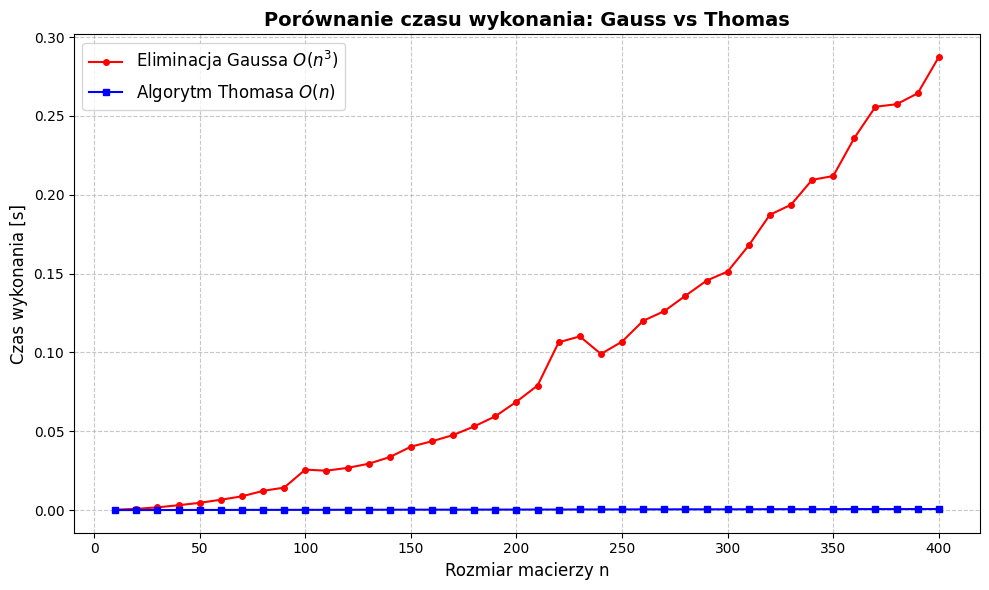

In [62]:
def plot_execution_time_comparison(max_n: int = 400, step: int = 10) -> None:
    """
    Measures and plots the execution time of Gaussian Elimination vs Thomas Algorithm.
    Generates a dense grid of n values to clearly demonstrate the O(n^3) vs O(n) 
    asymptotic behavior. Saves the plot directly to an image file.
    
    Parameters:
    ----------
    max_n : int
        The maximum matrix size to test (default 400).
    step : int
        The step size for the n grid (default 10).
    """
    n_values = list(range(10, max_n + 1, step))
    time_gauss = []
    time_thomas = []
    
    print(f"Starting time comparison experiment up to n={max_n}...")
    
    for n in n_values:
        # We use float64 as the baseline to show algorithmic complexity
        precision = np.float64
        
        # 1. Setup inputs
        A = generate_third_matrix(n, precision)
        x_ref = generate_x_vector(n, precision)
        b = calculate_b_vector(A, x_ref)
        
        diag_a = np.diag(A, k=-1)
        diag_b = np.diag(A, k=0)
        diag_c = np.diag(A, k=1)
        
        # 2. Measure Gaussian Elimination Time O(n^3)
        start_gauss = time.perf_counter()
        _ = gaussian_elimination(A, b, precision)
        end_gauss = time.perf_counter()
        time_gauss.append(end_gauss - start_gauss)
        
        # 3. Measure Thomas Algorithm Time O(n)
        start_thomas = time.perf_counter()
        _ = thomas_algorithm(diag_a, diag_b, diag_c, b, precision)
        end_thomas = time.perf_counter()
        time_thomas.append(end_thomas - start_thomas)
        
        # Progress indicator for the console
        if n % 50 == 0:
            print(f"Processed n = {n}/{max_n}")

    # 4. Generate the Plot
    plt.figure(figsize=(10, 6))
    
    # Plotting both series
    plt.plot(n_values, time_gauss, marker='o', markersize=4, linestyle='-', color='red', label='Eliminacja Gaussa $O(n^3)$')
    plt.plot(n_values, time_thomas, marker='s', markersize=4, linestyle='-', color='blue', label='Algorytm Thomasa $O(n)$')
    
    # Styling
    plt.title('Porównanie czasu wykonania: Gauss vs Thomas', fontsize=14, fontweight='bold')
    plt.xlabel('Rozmiar macierzy n', fontsize=12)
    plt.ylabel('Czas wykonania [s]', fontsize=12)
    
    plt.grid(True, linestyle="--", alpha=0.7)
    plt.legend(fontsize=12)
    plt.tight_layout()
    
    # 5. Save the Plot
    output_path = Path("plots/exercise3_time_comparison.png")
    output_path.parent.mkdir(parents=True, exist_ok=True)
    
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"Plot successfully generated and saved to: {output_path}")
    plt.show()
    
    plt.close()

plot_execution_time_comparison(max_n=400, step=10)